## Ch9. ARIMA models Forecasting: Principles & Practice (Python Edition) Extracted from: fpppy-09-arima.qmd

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## [Slide 2] Differencing

In [2]:
ap = pd.read_csv("data/AirPassengers.csv", parse_dates=["ds"])
y = ap.set_index("ds")["y"]


In [3]:
from statsmodels.tsa.stattools import kpss

stat, p_value, lags, crit = kpss(y, regression="c", nlags=5)
print(f"p-value = {p_value:.4f}")

p-value = 0.0100


/tmp/ipykernel_3713062/1940813477.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  stat, p_value, lags, crit = kpss(y, regression="c", nlags=5)


p < 0.05: reject stationarity => differencing required

## [Slide 4] Automated Differencing

In [4]:
from statsforecast.arima import ndiffs, nsdiffs

Number of first differences (uses sequence of KPSS tests)

In [5]:
d  = ndiffs(y, alpha=0.05, test="kpss", max_d=2)

Number of seasonal differences
(uses seasonal strength measure; recommends D=1 if Fs >= 0.64)

In [6]:
D  = nsdiffs(y, m=12, test="seas", max_D=1)

print(f"d = {d}, D = {D}")

ValueError: Non seasonal data

## [Slide 9] ACF/PACF Identification

In [7]:
y_diff = y.diff().dropna()


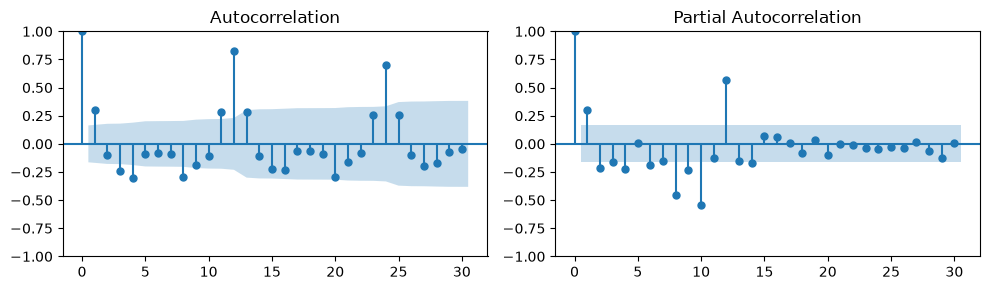

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(y_diff, lags=30, ax=axes[0])
plot_pacf(y_diff, lags=30, ax=axes[1])
plt.tight_layout()

## [Slide 14] The Hyndman-Khandakar AutoARIMA Algorithm

In [9]:
train = (
    ap.rename(columns={"y": "y"}).assign(unique_id="AirPassengers")
    [["unique_id", "ds", "y"]]
    .loc[lambda x: x["ds"] < "1959-01-01"]
)


In [10]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsforecast.arima import ARIMASummary

sf = StatsForecast(
    models=[AutoARIMA(season_length=12, stepwise=False)],
    freq="MS",
)
sf.fit(df=train)
arima_model = sf.fitted_[0, 0]
print(ARIMASummary(arima_model.model_))

ARIMA(0,1,3)(0,1,0)[12]                   


## [Slide 18] Ljung-Box Test and Residual Checks

In [11]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsforecast.arima import ARIMASummary

residuals = arima_model.model_["residuals"]
p, q = arima_model.model_["arma"][0], arima_model.model_["arma"][1]
K = p + q   # number of AR + MA parameters

lb_result = acorr_ljungbox(residuals, lags=[10], model_df=K)
print(lb_result)

     lb_stat  lb_pvalue
10  3.366194   0.849188


p > 0.05: residuals consistent with white noise

## [Slide 23] Empirical Comparison: Australian Population

In [12]:
from utilsforecast.evaluation import evaluate
train = pd.read_csv("data/aus_economy.csv", parse_dates=["ds"])


In [13]:
from statsforecast.models import AutoARIMA, AutoETS
from utilsforecast.losses import rmse, mae

sf = StatsForecast(
    models=[AutoARIMA(season_length=4), AutoETS(season_length=4)],
    freq="Q",
)
cv = sf.cross_validation(df=train, h=4, n_windows=10)
evaluate(cv.drop("cutoff", axis=1), metrics=[rmse, mae], train_df=train)

,unique_id,metric,AutoARIMA,AutoETS
0,Australia,rmse,332571.12500,385602.65625
1,Australia,mae,261590.84375,341102.90625
